# Heart Failure Prediction
Source: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

- Age: age of the patient [years]
- Sex: sex of the patient [M: Male, F: Female]
- ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
- RestingBP: resting blood pressure [mm Hg]
- Cholesterol: serum cholesterol [mm/dl]
- FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
- RestingECG: resting electrocardiogram results
  - [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
- MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
- ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
- Oldpeak: oldpeak = ST [Numeric value measured in depression]
- ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
- HeartDisease: output class [1: heart disease, 0: Normal]

# EDA
Get to know the data and have a feel of what are the features that would contribute to a person getting heart disease.

# Observation Summary
1. Data can be assumed to be balanced. No need to provide any treatment.
2. Numerical features seem to have correlation in some way with the label.
3. There is no concerns about multicollinearity.
4. Most of the numerical features seem to be normally distributed.
5. Heart disease seem to be more prevalent in males.
8. Characteristics of people with heart disease:
   - Those with asymptomatic chest pain
   - Those with flat and down ST_Slope
   - Those whose fasting blood sugar is above 120 mg/dl
   - Those whose resting ECG is not normal
   - Those who have exercise induced angina (chest pain when doing physical activity)
   - Those who are older
   - Those with lower max heart rate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# read file
df = pd.read_csv('./data/heart_failure_dataset.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [3]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


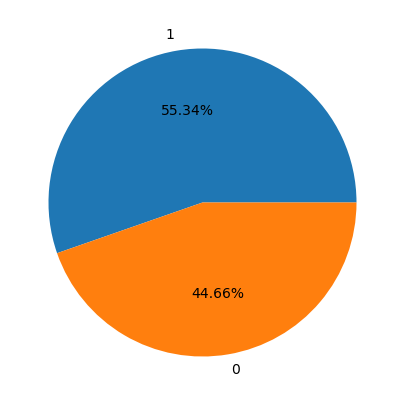

In [4]:
# see the proportion of the labels
df_heart_disease_counts = df['HeartDisease'].value_counts().reset_index()

plt.figure(figsize=(10, 5))
plt.pie(df_heart_disease_counts['count'], labels=df_heart_disease_counts['HeartDisease'], autopct='%0.2f%%')
plt.show()

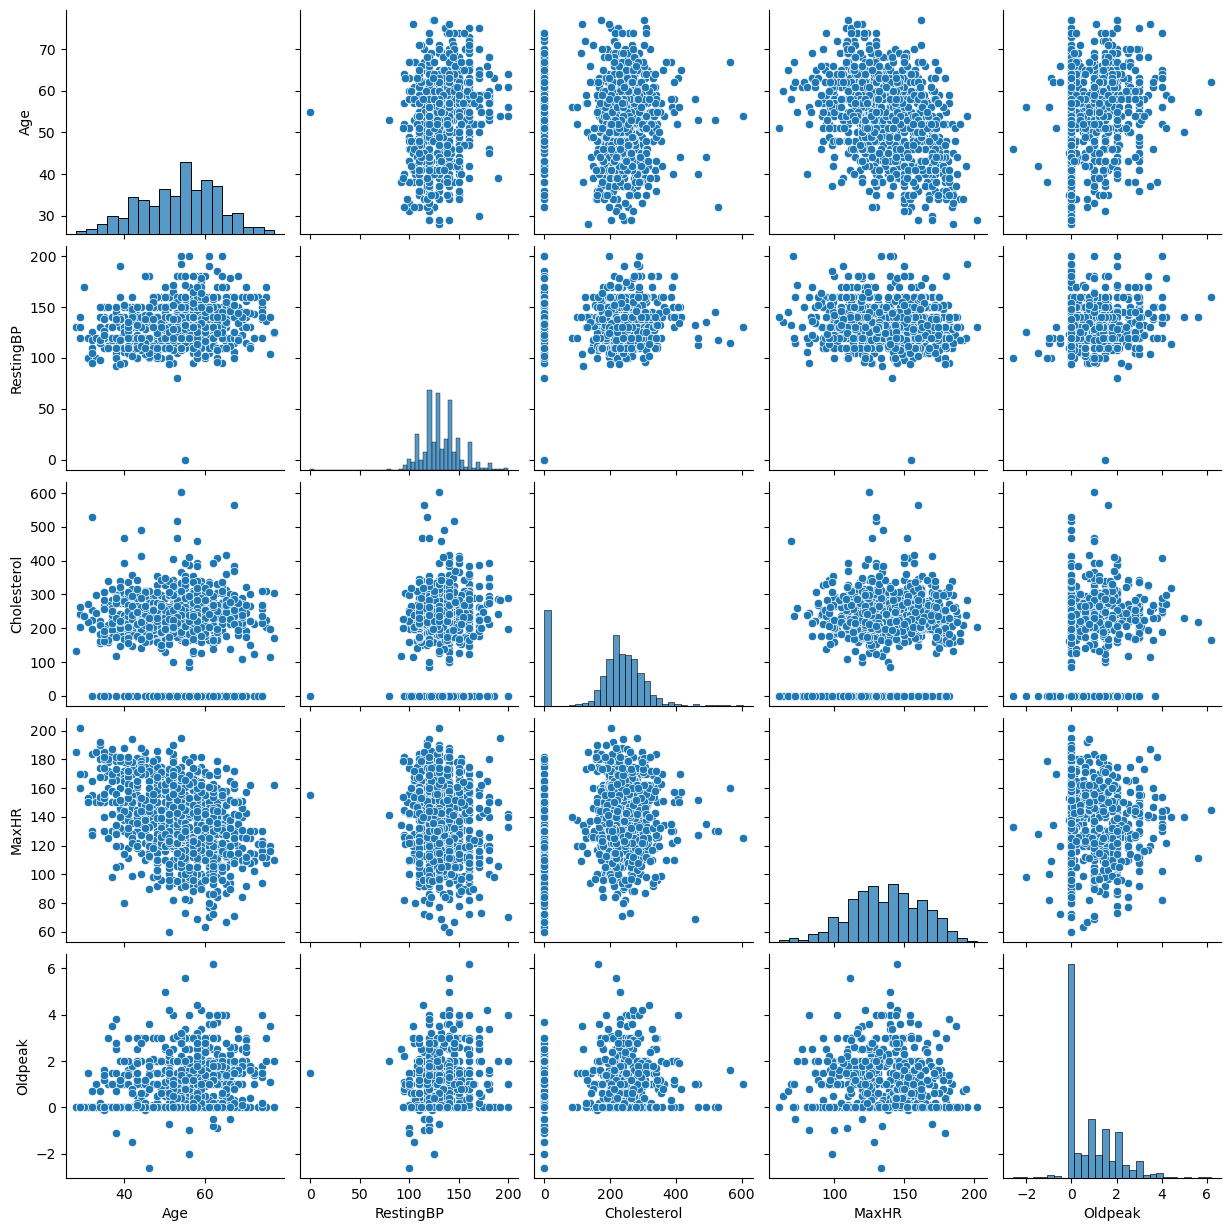

In [5]:
# plot the distribution of numerical features
## note that HeartDisease and FastingBS are categorical, no need to include
num_cols = [col for col in df.columns if df[col].dtype in ('int64', 'float64') and col not in ('HeartDisease', 'FastingBS')]

sns.pairplot(df[num_cols])
plt.show()

Other than some anomalies, the distribution of the numerical features seem to be normal and we can also observe some correlation between features.

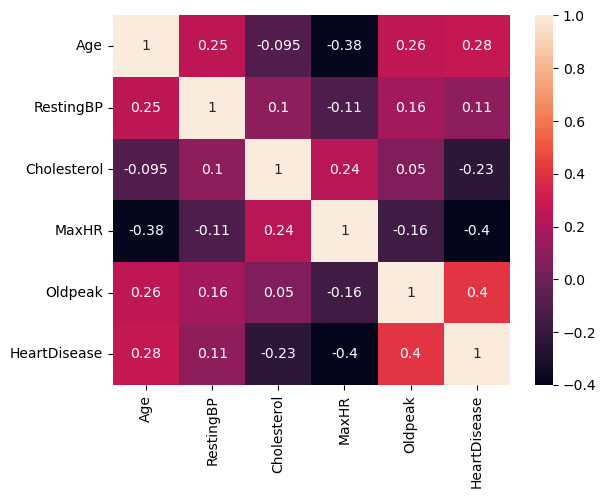

In [6]:
sns.heatmap(df[num_cols + ['HeartDisease']].corr(), annot=True)
plt.show()

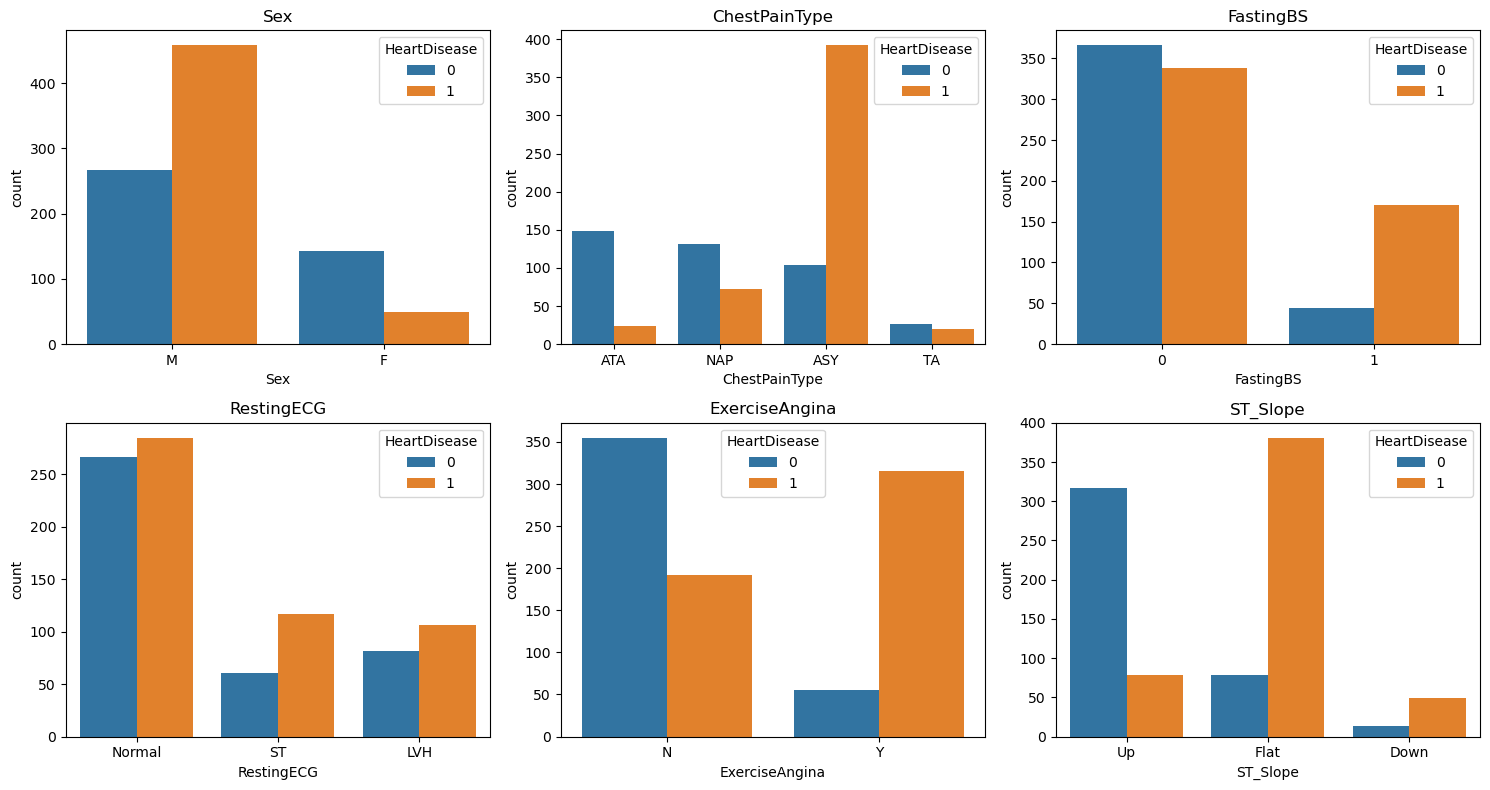

In [7]:
# create box plots or bar charts for categorical features
import math

cat_cols = [col for col in df.columns if df[col].dtype == 'object' or col == 'FastingBS']
num_plots =  len(cat_cols)
cols = 3
rows = math.ceil(num_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='HeartDisease', ax=axes[i])
    axes[i].set_title(f'{col}')
    # axes[i].tick_params(axis='x', rotation=45)

# hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

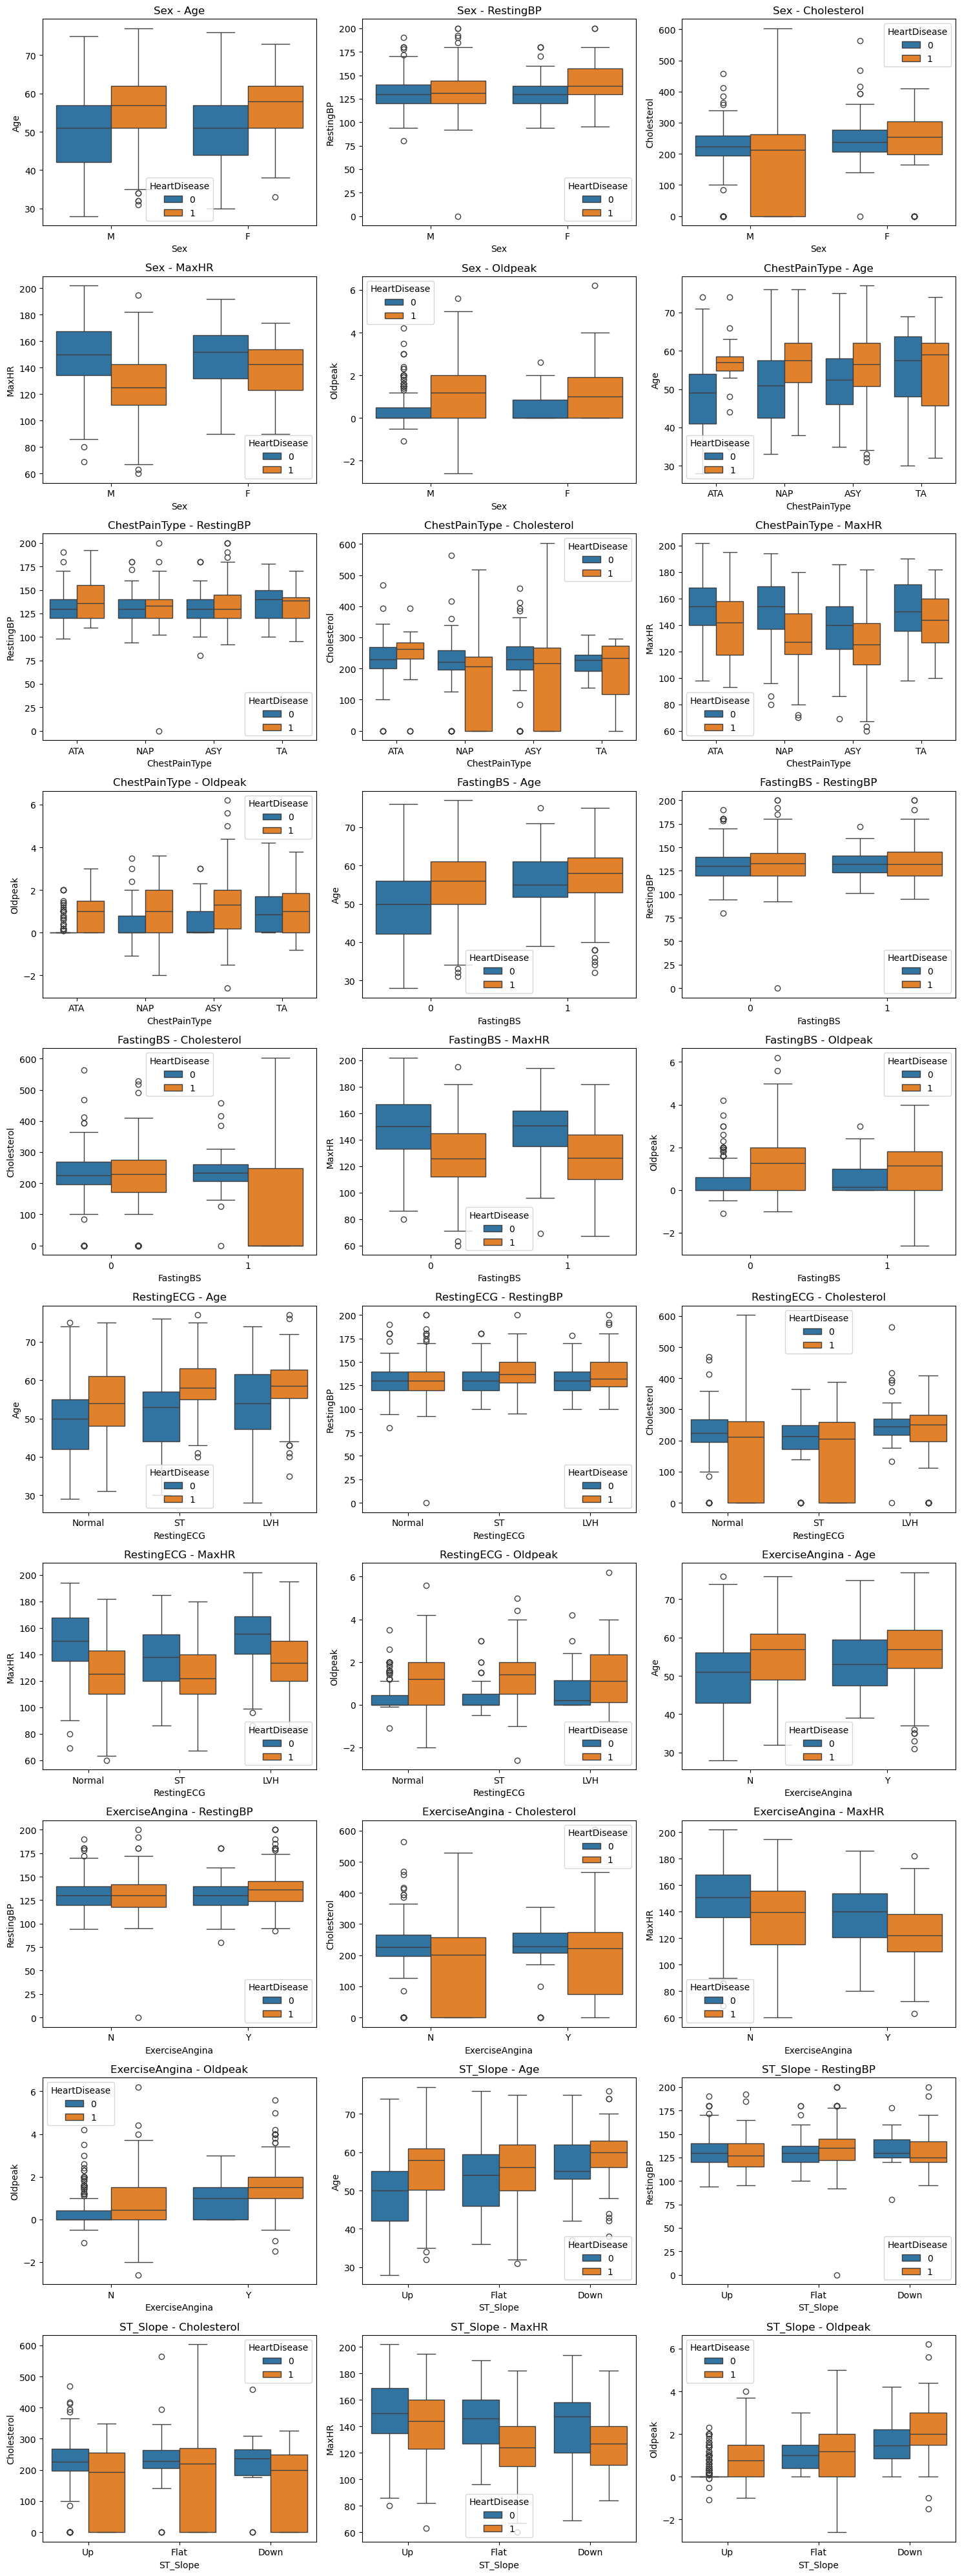

In [8]:
num_plots =  len(cat_cols) * len(num_cols)
cols = 3
rows = math.ceil(num_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

plot_idx = 0
for col in cat_cols:
    for num_col in num_cols:
        sns.boxplot(data=df, x=col, y=num_col, hue='HeartDisease', ax=axes[plot_idx])
        axes[plot_idx].set_title(f'{col} - {num_col}')
        plot_idx += 1

# hide unused axes
for j in range(plot_idx, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ML Modelling

## Models
This is a classificatin task, some of the models to test on for this project are:
- LogisticRegression
- DecisionTreeClassifier
- RandomForestClassifier
- XGBClassifier

## Metrics
Metrics to look at include:
- Accuracy (should be fine as labels are balanced)
- Precision
- Recall
- F1
- ROC curve (to check on test set, this metric is good for balanced dataset)
- Feature Importance (to get a sense of what features are contributing to a model's decision)
- SHAP value (to get an explanation from the model as to how they are predicting for a particular sample)

## Workflow
1. Split data into train and test sets.
2. Convert categorical features into numbers.
3. Scale numerical features.
4. Use RandomizedSearch or GridSearch to get the best hyperparameters.
5. Calculate the performance on the training data and validate against cross-validation performance.
6. Spot for overfitting and try to make the model less complex.
7. Choose the model and hyperparameters that performs the best or one that is peforming reasonably well.
8. Plot the shap value to get an explanation of the model's decision making.

In [9]:
# ML Modelling
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42)

print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (734, 11)
y_train: (734,)
X_test: (184, 11)
y_test: (184,)


In [11]:
X_train.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
485,63,M,ATA,139,217,1,ST,128,Y,1.2,Flat
486,55,M,ATA,110,214,1,ST,180,N,0.4,Up
117,59,F,ASY,130,338,1,ST,130,Y,1.5,Flat
361,47,M,ASY,160,0,0,Normal,124,Y,0.0,Flat
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat


In [12]:
# convert cat features to numbers but don't scale it
# scale numercial features with standard scaler
num_scaler = StandardScaler()
nom_encoder = OneHotEncoder(handle_unknown='ignore')
ord_encoder = OrdinalEncoder(
    categories=[
        # up is expected, down is concerning because it could indicate potential heart disease
        ['Up', 'Flat', 'Down']
    ]
)

numerical_columns = [col for col in X_train.columns if X_train[col].dtype in ('int64', 'float64') and col != 'FastingBS']
ordinal_columns = ['ST_Slope']
nominal_columns = [col for col in X_train.columns if (X_train[col].dtype == 'object' or col == 'FastingBS') and col != 'ST_Slope']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('ord', OrdinalEncoder(), ordinal_columns),
        ('nom', nom_encoder, nominal_columns)
    ]
)

print(numerical_columns)
print(ordinal_columns)
print(nominal_columns)

['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
['ST_Slope']
['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina']


In [13]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

X_train_transformed

array([[ 0.9700116 ,  0.3390158 ,  0.12713661, ...,  1.        ,
         0.        ,  1.        ],
       [ 0.12202766, -1.26603098,  0.09944299, ...,  1.        ,
         1.        ,  0.        ],
       [ 0.54601963, -0.15910217,  1.24411262, ...,  1.        ,
         0.        ,  1.        ],
       ...,
       [ 0.54601963, -0.60187369,  0.27483591, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.75801561, -0.43583437,  0.81947711, ...,  1.        ,
         0.        ,  1.        ],
       [-0.93795226,  0.39436224,  0.19175505, ...,  0.        ,
         1.        ,  0.        ]], shape=(734, 19))

In [14]:
feature_names = [feat.split('__')[1] for feat in preprocessor.get_feature_names_out()]

X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_train_transformed_df.head()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,ST_Slope,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,FastingBS_0,FastingBS_1,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y
0,0.970012,0.339016,0.127137,-0.324520,0.317046,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1,0.122028,-1.266031,0.099443,1.689837,-0.440356,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,0.546020,-0.159102,1.244113,-0.247045,0.601071,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
3,-0.725956,1.501291,-1.876035,-0.479470,-0.819056,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,-0.407962,0.671094,-1.876035,0.101594,-0.156330,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


In [15]:
# use random search to find best models
param_dist_lr = [
    {
        'penalty': ['l2'],
        'solver': ['lbfgs', 'newton-cholesky', 'sag'],
        'C': [0.01, 0.1, 1, 10]
    },
    {
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],
        'C': [0.01, 0.1, 1, 10]
    }
    
]

# using decision tree
param_dist_dt = {
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 4, 8],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['gini', 'entropy', 'log_loss']
}

# using random forest
param_dist_rf = {
    'n_estimators': [10, 50, 100, 150, 200],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 4, 8],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

param_dist_xgb = {
    'n_estimators': [10, 50, 100, 150, 200],
    'max_depth': [2, 4, 6, 8],
    'learning_rate': [0.0001, 0.001, 0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

NUM_ITER=50
CV=5
scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}

random_search_lr = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    n_iter=NUM_ITER,
    param_distributions=param_dist_lr,
    cv=CV,
    scoring=scoring,
    refit='accuracy',
    verbose=1,
    random_state=42
)

random_search_dt = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    n_iter=NUM_ITER,
    param_distributions=param_dist_dt,
    cv=CV,
    scoring=scoring,
    refit='accuracy',
    verbose=1,
    random_state=42
)

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    n_iter=NUM_ITER,
    param_distributions=param_dist_rf,
    cv=CV,
    scoring=scoring,
    refit='accuracy',
    verbose=1,
    random_state=42
)

random_search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    n_iter=NUM_ITER,
    param_distributions=param_dist_xgb,
    cv=CV,
    scoring=scoring,
    refit='accuracy',
    verbose=1,
    random_state=42
)

In [16]:
# train logistic regression model
random_search_lr.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Users/lpt814/anaconda3/envs/ds-personal-env/lib/python3.10/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 20 is smaller than n_iter=50. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_iter=50,
                   param_distributions=[{'C': [0.01, 0.1, 1, 10],
                                         'penalty': ['l2'],
                                         'solver': ['lbfgs', 'newton-cholesky',
                                                    'sag']},
                                        {'C': [0.01, 0.1, 1, 10],
                                         'penalty': ['l1'],
                                         'solver': ['liblinear', 'saga']}],
                   random_state=42, refit='accuracy',
                   scoring={'accuracy': 'accuracy', 'f1': 'f1',
                            'precision': 'precision', 'recall': 'recall'},
                   verbose=1)

In [17]:
random_search_lr_best_estimator = random_search_lr.best_estimator_
random_search_lr_best_results = random_search_lr.best_score_
random_search_lr_results_mean_acc = random_search_lr.cv_results_['mean_test_accuracy'].mean()
random_search_lr_results_mean_pre = random_search_lr.cv_results_['mean_test_precision'].mean()
random_search_lr_results_mean_rec = random_search_lr.cv_results_['mean_test_recall'].mean()
random_search_lr_results_mean_f1 = random_search_lr.cv_results_['mean_test_f1'].mean()

print(f"best estimator: {random_search_lr_best_estimator}")
print(f"best score: {random_search_lr_best_results}")
print(f"best cv results mean score accuracy: {random_search_lr_results_mean_acc}")
print(f"best cv results mean score precision: {random_search_lr_results_mean_pre}")
print(f"best cv results mean score recall: {random_search_lr_results_mean_rec}")
print(f"best cv results mean score f1: {random_search_lr_results_mean_f1}")

best estimator: LogisticRegression(C=0.1, max_iter=1000, penalty='l1', solver='saga')
best score: 0.8460068959090485
best cv results mean score accuracy: 0.8214672444320194
best cv results mean score precision: 0.8326146517965313
best cv results mean score recall: 0.8617329117735621
best cv results mean score f1: 0.8440103735739368


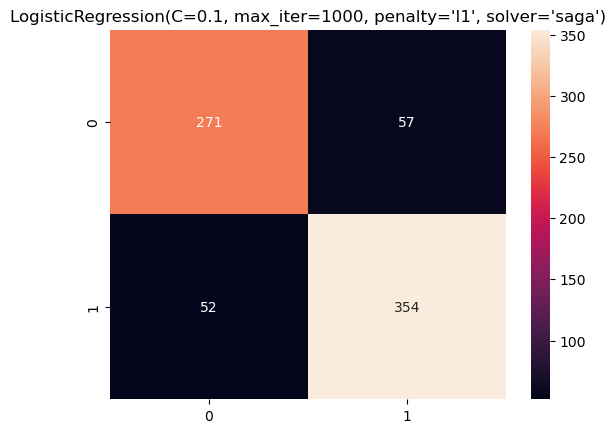

In [18]:
y_train_pred_random_lr = random_search_lr_best_estimator.predict(X_train_transformed)

cm_random_lr = confusion_matrix(y_train, y_train_pred_random_lr)
sns.heatmap(cm_random_lr, annot=True, fmt='d')
plt.title(f'{random_search_lr_best_estimator}')
plt.show()

In [19]:
print(classification_report(y_train, y_train_pred_random_lr))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83       328
           1       0.86      0.87      0.87       406

    accuracy                           0.85       734
   macro avg       0.85      0.85      0.85       734
weighted avg       0.85      0.85      0.85       734



In [20]:
# train decision tree
random_search_dt.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=50,
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [4, 6, 8],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 4, 8]},
                   random_state=42, refit='accuracy',
                   scoring={'accuracy': 'accuracy', 'f1': 'f1',
                            'precision': 'precision', 'recall': 'recall'},
                   verbose=1)

In [21]:
random_search_dt_best_estimator = random_search_dt.best_estimator_
random_search_dt_best_results = random_search_dt.best_score_
random_search_dt_results_mean_acc = random_search_dt.cv_results_['mean_test_accuracy'].mean()
random_search_dt_results_mean_pre = random_search_dt.cv_results_['mean_test_precision'].mean()
random_search_dt_results_mean_rec = random_search_dt.cv_results_['mean_test_recall'].mean()
random_search_dt_results_mean_f1 = random_search_dt.cv_results_['mean_test_f1'].mean()

print(f"best estimator: {random_search_dt_best_estimator}")
print(f"best score: {random_search_dt_best_results}")
print(f"best cv results mean score accuracy: {random_search_dt_results_mean_acc}")
print(f"best cv results mean score precision: {random_search_dt_results_mean_pre}")
print(f"best cv results mean score recall: {random_search_dt_results_mean_rec}")
print(f"best cv results mean score f1: {random_search_dt_results_mean_f1}")

best estimator: DecisionTreeClassifier(criterion='log_loss', max_depth=4, min_samples_leaf=2,
                       min_samples_split=8, random_state=42)
best score: 0.8364364924051813
best cv results mean score accuracy: 0.8160335476656416
best cv results mean score precision: 0.8368968701891588
best cv results mean score recall: 0.8315176151761517
best cv results mean score f1: 0.8331409524417043


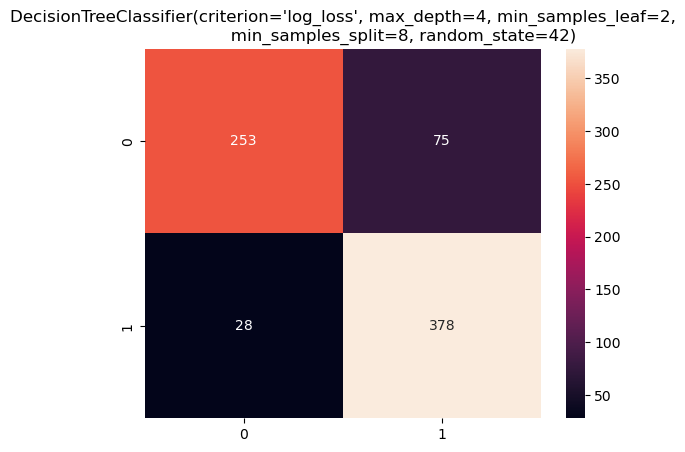

In [22]:
y_train_pred_random_dt = random_search_dt_best_estimator.predict(X_train_transformed)

cm_random_dt = confusion_matrix(y_train, y_train_pred_random_dt)
sns.heatmap(cm_random_dt, annot=True, fmt='d')
plt.title(f'{random_search_dt_best_estimator}')
plt.show()

In [23]:
print(classification_report(y_train, y_train_pred_random_dt))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83       328
           1       0.83      0.93      0.88       406

    accuracy                           0.86       734
   macro avg       0.87      0.85      0.86       734
weighted avg       0.86      0.86      0.86       734



In [24]:
# train random forest
random_search_rf.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=50,
                   param_distributions={'max_depth': [4, 6, 8],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 4, 8],
                                        'n_estimators': [10, 50, 100, 150,
                                                         200]},
                   random_state=42, refit='accuracy',
                   scoring={'accuracy': 'accuracy', 'f1': 'f1',
                            'precision': 'precision', 'recall': 'recall'},
                   verbose=1)

In [25]:
random_search_rf_best_estimator = random_search_rf.best_estimator_
random_search_rf_best_results = random_search_rf.best_score_
random_search_rf_results_mean_acc = random_search_rf.cv_results_['mean_test_accuracy'].mean()
random_search_rf_results_mean_pre = random_search_rf.cv_results_['mean_test_precision'].mean()
random_search_rf_results_mean_rec = random_search_rf.cv_results_['mean_test_recall'].mean()
random_search_rf_results_mean_f1 = random_search_rf.cv_results_['mean_test_f1'].mean()

print(f"best estimator: {random_search_rf_best_estimator}")
print(f"best score: {random_search_rf_best_results}")
print(f"best cv results mean score accuracy: {random_search_rf_results_mean_acc}")
print(f"best cv results mean score precision: {random_search_rf_results_mean_pre}")
print(f"best cv results mean score recall: {random_search_rf_results_mean_rec}")
print(f"best cv results mean score f1: {random_search_rf_results_mean_f1}")

best estimator: RandomForestClassifier(max_depth=6, max_features=None, min_samples_split=4,
                       n_estimators=10, random_state=42)
best score: 0.862361382909328
best cv results mean score accuracy: 0.8540974746062808
best cv results mean score precision: 0.8537003012803227
best cv results mean score recall: 0.890139716952725
best cv results mean score f1: 0.8709442709199767


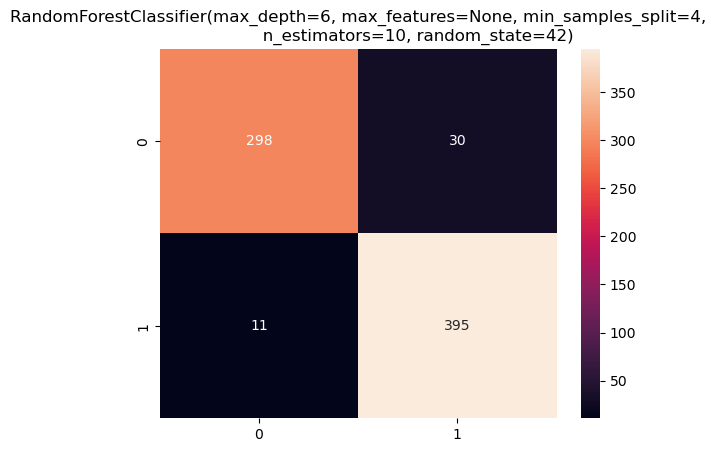

In [26]:
y_train_pred_random_rf = random_search_rf_best_estimator.predict(X_train_transformed)

cm_random_rf = confusion_matrix(y_train, y_train_pred_random_rf)
sns.heatmap(cm_random_rf, annot=True, fmt='d')
plt.title(f'{random_search_rf_best_estimator}')
plt.show()

In [27]:
print(classification_report(y_train, y_train_pred_random_rf))

              precision    recall  f1-score   support

           0       0.96      0.91      0.94       328
           1       0.93      0.97      0.95       406

    accuracy                           0.94       734
   macro avg       0.95      0.94      0.94       734
weighted avg       0.95      0.94      0.94       734



In [28]:
# train xgb classifier
random_search_xgb.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=50,
                   param_distributions={'colsample_bytree': [0.8, 1],
                                        'learning_rate': [0.0001, 0.001, 0.01,
                                                          0.1],
                                        'max_depth': [2, 4, 6, 8],
                                        'n_estimators': [10, 50, 100, 150, 200],
                                        'subsample': [0.8, 1]},
                   random_state=42, refit='accuracy',
                   scoring={'accuracy': 'accuracy', 'f1': 'f1',
                            'precision': 'precision', 'recall': 'recall'},
                   verbose=1)

In [29]:
random_search_xgb_best_estimator = random_search_xgb.best_estimator_
random_search_xgb_best_results = random_search_xgb.best_score_
random_search_xgb_results_mean_acc = random_search_xgb.cv_results_['mean_test_accuracy'].mean()
random_search_xgb_results_mean_pre = random_search_xgb.cv_results_['mean_test_precision'].mean()
random_search_xgb_results_mean_rec = random_search_xgb.cv_results_['mean_test_recall'].mean()
random_search_xgb_results_mean_f1 = random_search_xgb.cv_results_['mean_test_f1'].mean()

print(f"best estimator: {random_search_xgb_best_estimator}")
print(f"best score: {random_search_xgb_best_results}")
print(f"best cv results mean score accuracy: {random_search_xgb_results_mean_acc}")
print(f"best cv results mean score precision: {random_search_xgb_results_mean_pre}")
print(f"best cv results mean score recall: {random_search_xgb_results_mean_rec}")
print(f"best cv results mean score f1: {random_search_xgb_results_mean_f1}")

best estimator: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)
best score: 0.8677662845960301
best cv results mean score accuracy: 0.6540980337340414
best cv results mean score precision: 0.6483779148268005
best cv results mean score recall: 0.9685383920505872
best cv results mean score f

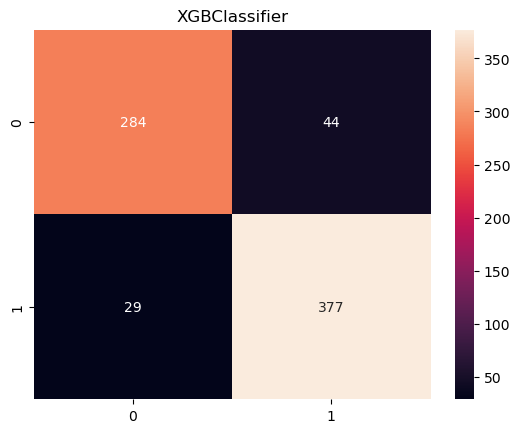

In [30]:
y_train_pred_random_xgb = random_search_xgb_best_estimator.predict(X_train_transformed)

cm_random_xgb = confusion_matrix(y_train, y_train_pred_random_xgb)
sns.heatmap(cm_random_xgb, annot=True, fmt='d')
plt.title(f'XGBClassifier')
plt.show()

In [31]:
print(classification_report(y_train, y_train_pred_random_xgb))

              precision    recall  f1-score   support

           0       0.91      0.87      0.89       328
           1       0.90      0.93      0.91       406

    accuracy                           0.90       734
   macro avg       0.90      0.90      0.90       734
weighted avg       0.90      0.90      0.90       734



In [32]:
param_grid_lr = {
    'penalty': ['l1'],
    'solver': ['liblinear', 'saga'],
    'C': [0.001, 0.01, 0.1, 1, 10]
}

param_grid_dt = {
    'max_depth': [2, 4, 6],
    'min_samples_split': [2, 4, 8],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'log_loss', 'entropy']
}

param_grid_rf = {
    'n_estimators': [50, 100, 150, 200, 250],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 4, 8],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

param_grid_xgb = {
    'n_estimators': [100, 150, 200],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.0001, 0.001, 0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

from sklearn.metrics import make_scorer
scoring = {
    'accuracy': make_scorer(accuracy_score), 
    'precision': make_scorer(precision_score, zero_division=0), 
    'recall': make_scorer(recall_score, zero_division=0), 
    'f1': make_scorer(f1_score, zero_division=0)
}

grid_search_lr = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid_lr,
    cv=5,
    scoring=scoring,
    refit='accuracy',
    verbose=1
)

grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=5,
    scoring=scoring,
    refit='accuracy',
    verbose=1
)

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring=scoring,
    refit='accuracy',
    verbose=1
)

grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=param_grid_xgb,
    cv=5,
    scoring=scoring,
    refit='accuracy',
    verbose=1
)

In [33]:
def plot_confusion_matrix(y_test, y_pred, set_title):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(set_title)
    plt.show()

In [34]:
# train with grid_search log regression
grid_search_lr.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10], 'penalty': ['l1'],
                         'solver': ['liblinear', 'saga']},
             refit='accuracy',
             scoring={'accuracy': make_scorer(accuracy_score, response_method='predict'),
                      'f1': make_scorer(f1_score, response_method='predict', zero_division=0),
                      'precision': make_scorer(precision_score, response_method='predict', zero_division=0),
                      'recall': make_scorer(recall_score, response_method='predict', zero_division=0)},
             verbose=1)

In [35]:
grid_search_lr_best_estimator = grid_search_lr.best_estimator_
grid_search_lr_best_score = grid_search_lr.best_score_
grid_search_lr_results_mean_acc = grid_search_lr.cv_results_['mean_test_accuracy'].mean()
grid_search_lr_results_mean_pre = grid_search_lr.cv_results_['mean_test_precision'].mean()
grid_search_lr_results_mean_rec = grid_search_lr.cv_results_['mean_test_recall'].mean()
grid_search_lr_results_mean_f1 = grid_search_lr.cv_results_['mean_test_f1'].mean()

print(f"best estimator: {grid_search_lr_best_estimator}")
print(f"best score: {grid_search_lr_best_score}")
print(f"best cv results mean score accuracy: {grid_search_lr_results_mean_acc}")
print(f"best cv results mean score precision: {grid_search_lr_results_mean_pre}")
print(f"best cv results mean score recall: {grid_search_lr_results_mean_rec}")
print(f"best cv results mean score f1: {grid_search_lr_results_mean_f1}")

best estimator: LogisticRegression(C=0.1, max_iter=1000, penalty='l1', solver='saga')
best score: 0.8460068959090485
best cv results mean score accuracy: 0.7355204547572454
best cv results mean score precision: 0.7025724873244829
best cv results mean score recall: 0.7839265281541705
best cv results mean score f1: 0.7311541385474577


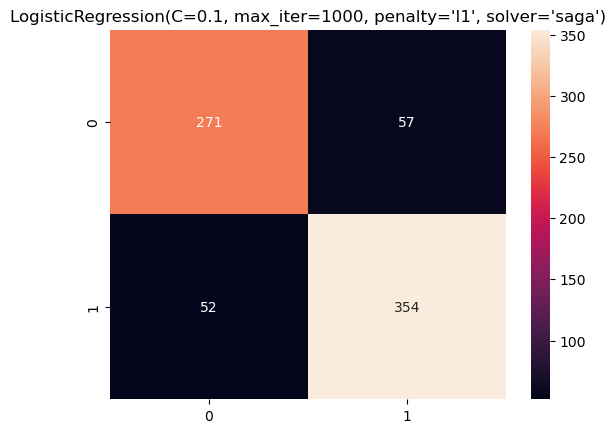

In [36]:
y_train_pred_grid_lr = grid_search_lr_best_estimator.predict(X_train_transformed)

plot_confusion_matrix(y_train, y_train_pred_grid_lr, grid_search_lr_best_estimator)

In [37]:
print(classification_report(y_train, y_train_pred_grid_lr))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83       328
           1       0.86      0.87      0.87       406

    accuracy                           0.85       734
   macro avg       0.85      0.85      0.85       734
weighted avg       0.85      0.85      0.85       734



In [38]:
# train with grid_search decision tree
grid_search_dt.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'log_loss', 'entropy'],
                         'max_depth': [2, 4, 6], 'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 4, 8]},
             refit='accuracy',
             scoring={'accuracy': make_scorer(accuracy_score, response_method='predict'),
                      'f1': make_scorer(f1_score, response_method='predict', zero_division=0),
                      'precision': make_scorer(precision_score, response_method='predict', zero_division=0),
                      'recall': make_scorer(recall_score, response_method='predict', zero_division=0)},
             verbose=1)

In [39]:
grid_search_dt_best_estimator = grid_search_dt.best_estimator_
grid_search_dt_best_score = grid_search_dt.best_score_
grid_search_dt_results_mean_acc = grid_search_dt.cv_results_['mean_test_accuracy'].mean()
grid_search_dt_results_mean_pre = grid_search_dt.cv_results_['mean_test_precision'].mean()
grid_search_dt_results_mean_rec = grid_search_dt.cv_results_['mean_test_recall'].mean()
grid_search_dt_results_mean_f1 = grid_search_dt.cv_results_['mean_test_f1'].mean()

print(f"best estimator: {grid_search_dt_best_estimator}")
print(f"best score: {grid_search_dt_best_score}")
print(f"best cv results mean score accuracy: {grid_search_dt_results_mean_acc}")
print(f"best cv results mean score precision: {grid_search_dt_results_mean_pre}")
print(f"best cv results mean score recall: {grid_search_dt_results_mean_rec}")
print(f"best cv results mean score f1: {grid_search_dt_results_mean_f1}")

best estimator: DecisionTreeClassifier(criterion='log_loss', max_depth=4, min_samples_leaf=2,
                       random_state=42)
best score: 0.8364364924051813
best cv results mean score accuracy: 0.8257847634233804
best cv results mean score precision: 0.8422152527494661
best cv results mean score recall: 0.8451953710209255
best cv results mean score f1: 0.8427685828305724


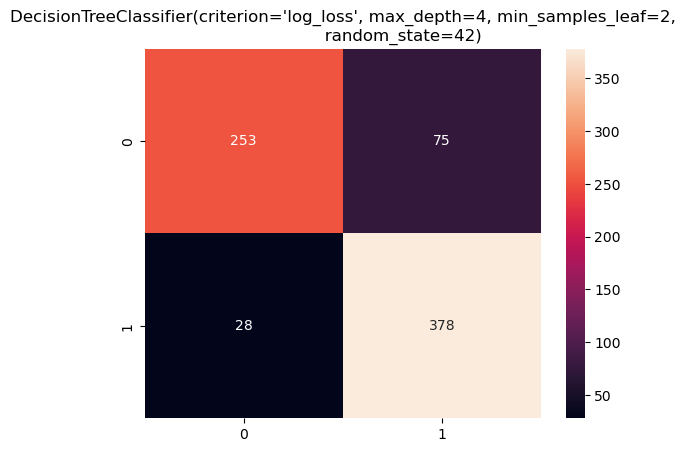

In [40]:
y_train_pred_grid_dt = grid_search_dt_best_estimator.predict(X_train_transformed)

plot_confusion_matrix(y_train, y_train_pred_grid_dt, grid_search_dt_best_estimator)

In [41]:
print(classification_report(y_train, y_train_pred_grid_dt))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83       328
           1       0.83      0.93      0.88       406

    accuracy                           0.86       734
   macro avg       0.87      0.85      0.86       734
weighted avg       0.86      0.86      0.86       734



In [42]:
# train with grid_search random forest
grid_search_rf.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 405 candidates, totalling 2025 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [4, 6, 8],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 4, 8],
                         'n_estimators': [50, 100, 150, 200, 250]},
             refit='accuracy',
             scoring={'accuracy': make_scorer(accuracy_score, response_method='predict'),
                      'f1': make_scorer(f1_score, response_method='predict', zero_division=0),
                      'precision': make_scorer(precision_score, response_method='predict', zero_division=0),
                      'recall': make_scorer(recall_score, response_method='predict', zero_division=0)},
             verbose=1)

In [43]:
grid_search_rf_best_estimator = grid_search_rf.best_estimator_
grid_search_rf_best_score = grid_search_rf.best_score_
grid_search_rf_results_mean_acc = grid_search_rf.cv_results_['mean_test_accuracy'].mean()
grid_search_rf_results_mean_pre = grid_search_rf.cv_results_['mean_test_precision'].mean()
grid_search_rf_results_mean_rec = grid_search_rf.cv_results_['mean_test_recall'].mean()
grid_search_rf_results_mean_f1 = grid_search_rf.cv_results_['mean_test_f1'].mean()

print(f"best estimator: {grid_search_rf_best_estimator}")
print(f"best score: {grid_search_rf_best_score}")
print(f"best cv results mean score accuracy: {grid_search_rf_results_mean_acc}")
print(f"best cv results mean score precision: {grid_search_rf_results_mean_pre}")
print(f"best cv results mean score recall: {grid_search_rf_results_mean_rec}")
print(f"best cv results mean score f1: {grid_search_rf_results_mean_f1}")

best estimator: RandomForestClassifier(max_depth=8, min_samples_split=8, random_state=42)
best score: 0.8650731525486908
best cv results mean score accuracy: 0.8544964341224398
best cv results mean score precision: 0.8536052356377513
best cv results mean score recall: 0.8911271705309645
best cv results mean score f1: 0.8713752582987893


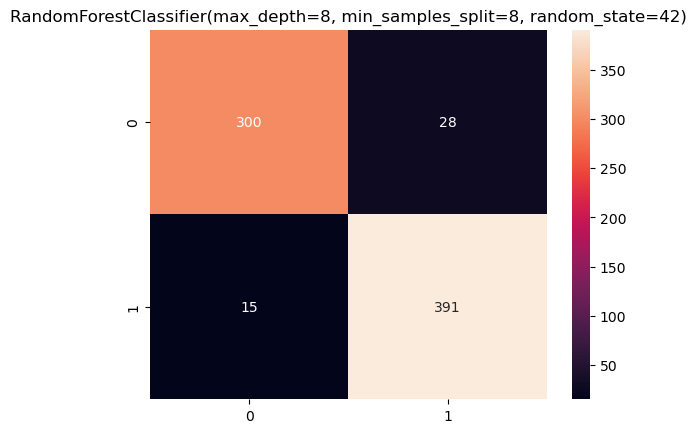

In [44]:
y_train_pred_grid_rf = grid_search_rf_best_estimator.predict(X_train_transformed)

plot_confusion_matrix(y_train, y_train_pred_grid_rf, grid_search_rf_best_estimator)

In [45]:
print(classification_report(y_train, y_train_pred_grid_rf))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93       328
           1       0.93      0.96      0.95       406

    accuracy                           0.94       734
   macro avg       0.94      0.94      0.94       734
weighted avg       0.94      0.94      0.94       734



In [46]:
grid_search_xgb.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 192 candidates, totalling 960 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                         'subsample': [0.8, 1]},
             refit='accuracy',
             scoring={'accuracy': make_scorer(accuracy_score, response_method='predict'),
                      'f1': make_scorer(f1_score, response_method='predict', zero_division=0),
                      'precision': make_scorer(precision_score, response_method='predict', zero_division=0),
                      'recall': make_scorer(recall_score, response_method='predict', zero_division=0)},
             verbose=1)

In [47]:
grid_search_xgb_best_estimator = grid_search_xgb.best_estimator_
grid_search_xgb_best_score = grid_search_xgb.best_score_
grid_search_xgb_results_mean_acc = grid_search_xgb.cv_results_['mean_test_accuracy'].mean()
grid_search_xgb_results_mean_pre = grid_search_xgb.cv_results_['mean_test_precision'].mean()
grid_search_xgb_results_mean_rec = grid_search_xgb.cv_results_['mean_test_recall'].mean()
grid_search_xgb_results_mean_f1 = grid_search_xgb.cv_results_['mean_test_f1'].mean()

print(f"best estimator: {grid_search_xgb_best_estimator}")
print(f"best score: {grid_search_xgb_best_score}")
print(f"best cv results mean score accuracy: {grid_search_xgb_results_mean_acc}")
print(f"best cv results mean score precision: {grid_search_xgb_results_mean_pre}")
print(f"best cv results mean score recall: {grid_search_xgb_results_mean_rec}")
print(f"best cv results mean score f1: {grid_search_xgb_results_mean_f1}")

best estimator: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)
best score: 0.8677662845960301
best cv results mean score accuracy: 0.7444462887894884
best cv results mean score precision: 0.7372452633396674
best cv results mean score recall: 0.9371799094148349
best cv results mean score f

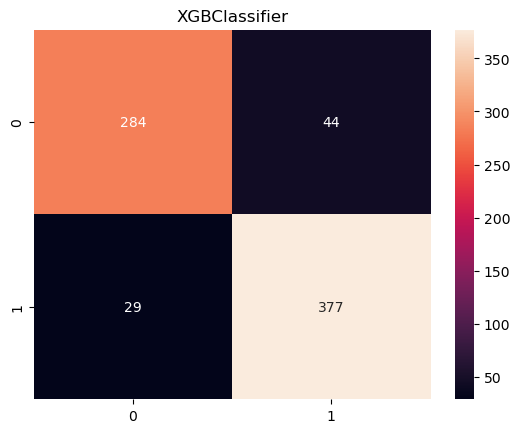

In [48]:
y_train_pred_grid_xgb = grid_search_xgb_best_estimator.predict(X_train_transformed)

plot_confusion_matrix(y_train, y_train_pred_grid_xgb, 'XGBClassifier')

In [49]:
print(classification_report(y_train, y_train_pred_grid_xgb))

              precision    recall  f1-score   support

           0       0.91      0.87      0.89       328
           1       0.90      0.93      0.91       406

    accuracy                           0.90       734
   macro avg       0.90      0.90      0.90       734
weighted avg       0.90      0.90      0.90       734



In [50]:
models = [
    random_search_lr, random_search_dt, 
    random_search_rf, random_search_xgb,
    grid_search_lr, grid_search_dt, 
    grid_search_rf, grid_search_xgb
]

model_names = [
    'random_search_lr', 'random_search_dt', 'random_search_rf', 'random_search_xgb',
    'grid_search_lr', 'grid_search_dt', 'grid_search_rf', 'grid_search_xgb'
]


results = []

# get training performance metrics
for name, model in zip(model_names, models):
    y_pred = model.best_estimator_.predict(X_train_transformed)
    
    precision = precision_score(y_train, y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train, y_pred)
    accuracy = accuracy_score(y_train, y_pred)
    
    results.append({
        'model': name,
        'precision_train': precision,
        'precision_cv': model.cv_results_['mean_test_precision'].mean(),
        'recall_train': recall,
        'recall_cv': model.cv_results_['mean_test_recall'].mean(),
        'f1_train': f1,
        'f1_cv': model.cv_results_['mean_test_f1'].mean(),
        'accuracy_train': accuracy,
        'accuracy_cv': model.cv_results_['mean_test_accuracy'].mean(),
    })

results_df = pd.DataFrame(results)

In [51]:
results_df

,model,precision_train,precision_cv,recall_train,recall_cv,f1_train,f1_cv,accuracy_train,accuracy_cv
0,random_search_lr,0.861314,0.832615,0.871921,0.861733,0.866585,0.844010,0.851499,0.821467
1,random_search_dt,0.834437,0.836897,0.931034,0.831518,0.880093,0.833141,0.859673,0.816034
2,random_search_rf,0.929412,0.853700,0.972906,0.890140,0.950662,0.870944,0.944142,0.854097
3,random_search_xgb,0.895487,0.648378,0.928571,0.968538,0.911729,0.765245,0.900545,0.654098
4,grid_search_lr,0.861314,0.702572,0.871921,0.783927,0.866585,0.731154,0.851499,0.735520
5,grid_search_dt,0.834437,0.842215,0.931034,0.845195,0.880093,0.842769,0.859673,0.825785
6,grid_search_rf,0.933174,0.853605,0.963054,0.891127,0.947879,0.871375,0.941417,0.854496
7,grid_search_xgb,0.895487,0.737245,0.928571,0.937180,0.911729,0.812882,0.900545,0.744446


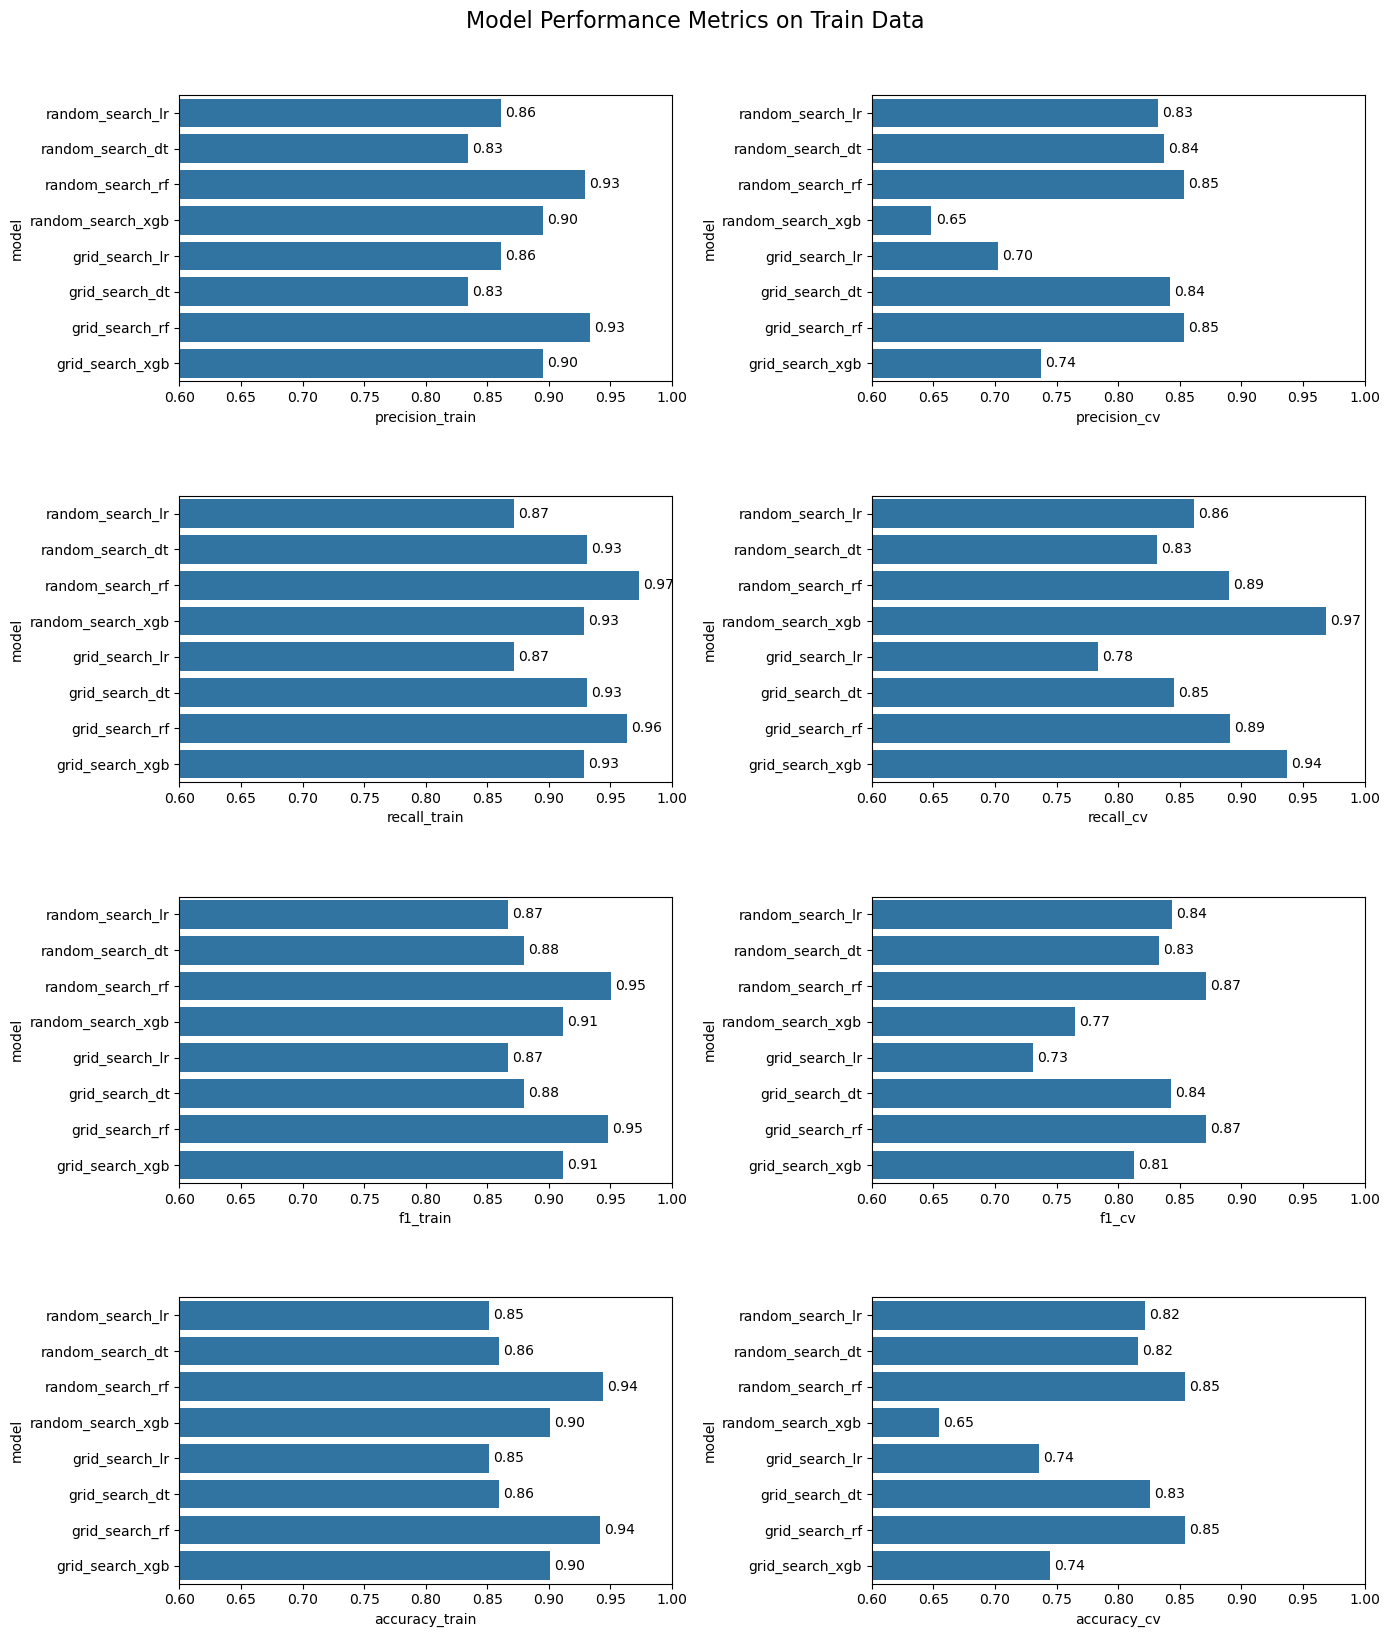

In [52]:
metric_cols = [col for col in results_df.columns.tolist()[1:]]

cols = 2
rows = math.ceil(len(metric_cols) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(metric_cols):
    ax = axes[i]
    sns.barplot(data=results_df, x=col, y='model', ax=ax)
    ax.set_xlim(xmin=0.6, xmax=1)
    ax.set_xlabel(col)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)

# hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Model Performance Metrics on Train Data', fontsize=16, y=1.02)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

In [53]:
# try tuning xgb
param_grid_xgb_2 = {
    'n_estimators': [70, 80, 90],
    'max_depth': [2],
    'learning_rate': [0.01, 0.1]
}

grid_search_xgb_2 = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=param_grid_xgb_2,
    cv=5,
    scoring=scoring,
    refit='accuracy',
    verbose=1
)

In [54]:
grid_search_xgb_2.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                         'n_estimators': [70, 80, 90]},
             refit='accuracy',
             scoring={'accuracy': make_scorer(accuracy_score, response_method='predict'),
                      'f1': make_scorer(f1_score, response_method='predict', zero_division=0),
                      'precision': make_scorer(precision_score, response_method='predict', zero_division=0),
                      'recall': make_scorer(recall_score, response_method='predict', zero_division=0)},
             verbose=1)

In [55]:
grid_search_xgb_2_best_estimator = grid_search_xgb_2.best_estimator_
grid_search_xgb_2_best_score = grid_search_xgb_2.best_score_
grid_search_xgb_2_results_mean_acc = grid_search_xgb_2.cv_results_['mean_test_accuracy'].mean()
grid_search_xgb_2_results_mean_pre = grid_search_xgb_2.cv_results_['mean_test_precision'].mean()
grid_search_xgb_2_results_mean_rec = grid_search_xgb_2.cv_results_['mean_test_recall'].mean()
grid_search_xgb_2_results_mean_f1 = grid_search_xgb_2.cv_results_['mean_test_f1'].mean()

print(f"best estimator: {grid_search_xgb_2_best_estimator}")
print(f"best score: {grid_search_xgb_2_best_score}")
print(f"best cv results mean score accuracy: {grid_search_xgb_2_results_mean_acc}")
print(f"best cv results mean score precision: {grid_search_xgb_2_results_mean_pre}")
print(f"best cv results mean score recall: {grid_search_xgb_2_results_mean_rec}")
print(f"best cv results mean score f1: {grid_search_xgb_2_results_mean_f1}")

best estimator: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=70, n_jobs=None,
              num_parallel_tree=None, ...)
best score: 0.8677942409840649
best cv results mean score accuracy: 0.8505404901686702
best cv results mean score precision: 0.8498756129952055
best cv results mean score recall: 0.8877747666365551
best cv resu

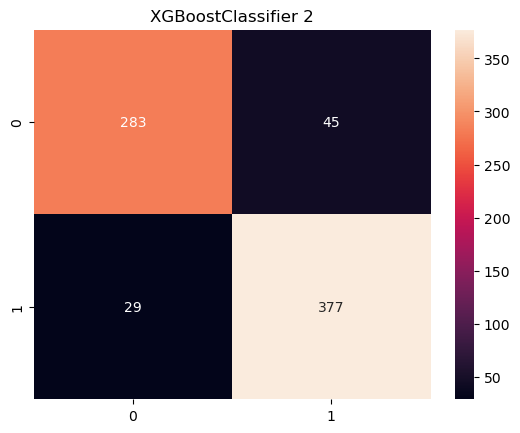

In [56]:
y_train_pred_grid_xgb_2 = grid_search_xgb_2_best_estimator.predict(X_train_transformed)

plot_confusion_matrix(y_train, y_train_pred_grid_xgb_2, 'XGBoostClassifier 2')

In [57]:
print(classification_report(y_train, y_train_pred_grid_xgb_2))

              precision    recall  f1-score   support

           0       0.91      0.86      0.88       328
           1       0.89      0.93      0.91       406

    accuracy                           0.90       734
   macro avg       0.90      0.90      0.90       734
weighted avg       0.90      0.90      0.90       734



In [58]:
grid_xgb_2_pre = precision_score(y_train, y_train_pred_grid_xgb_2)
grid_xgb_2_rec = recall_score(y_train, y_train_pred_grid_xgb_2)
grid_xgb_2_f1 = f1_score(y_train, y_train_pred_grid_xgb_2)
grid_xgb_2_acc = accuracy_score(y_train, y_train_pred_grid_xgb_2)

print(f'Train precision: {grid_xgb_2_pre} | CV precision: {grid_search_xgb_2_results_mean_pre}')
print(f'Train recall: {grid_xgb_2_rec} | CV recall: {grid_search_xgb_2_results_mean_rec}')
print(f'Train f1: {grid_xgb_2_f1} | CV f1: {grid_search_xgb_2_results_mean_f1}')
print(f'Train accuracy: {grid_xgb_2_acc} | CV accuracy: {grid_search_xgb_2_results_mean_acc}')

Train precision: 0.8933649289099526 | CV precision: 0.8498756129952055
Train recall: 0.9285714285714286 | CV recall: 0.8877747666365551
Train f1: 0.9106280193236715 | CV f1: 0.8678816556726354
Train accuracy: 0.8991825613079019 | CV accuracy: 0.8505404901686702


In [59]:
results_2 = results
results_2.append({
    'model': 'grid_search_xgb_2',
    'precision_train': grid_xgb_2_pre,
    'precision_cv': grid_search_xgb_2_results_mean_pre,
    'recall_train': grid_xgb_2_rec,
    'recall_cv': grid_search_xgb_2_results_mean_rec,
    'f1_train': grid_xgb_2_f1,
    'f1_cv': grid_search_xgb_2_results_mean_f1,
    'accuracy_train': grid_xgb_2_acc,
    'accuracy_cv': grid_search_xgb_2_results_mean_acc,
})

results_2_df = pd.DataFrame(results_2)
results_2_df.head()

,model,precision_train,precision_cv,recall_train,recall_cv,f1_train,f1_cv,accuracy_train,accuracy_cv
0,random_search_lr,0.861314,0.832615,0.871921,0.861733,0.866585,0.844010,0.851499,0.821467
1,random_search_dt,0.834437,0.836897,0.931034,0.831518,0.880093,0.833141,0.859673,0.816034
2,random_search_rf,0.929412,0.853700,0.972906,0.890140,0.950662,0.870944,0.944142,0.854097
3,random_search_xgb,0.895487,0.648378,0.928571,0.968538,0.911729,0.765245,0.900545,0.654098
4,grid_search_lr,0.861314,0.702572,0.871921,0.783927,0.866585,0.731154,0.851499,0.735520


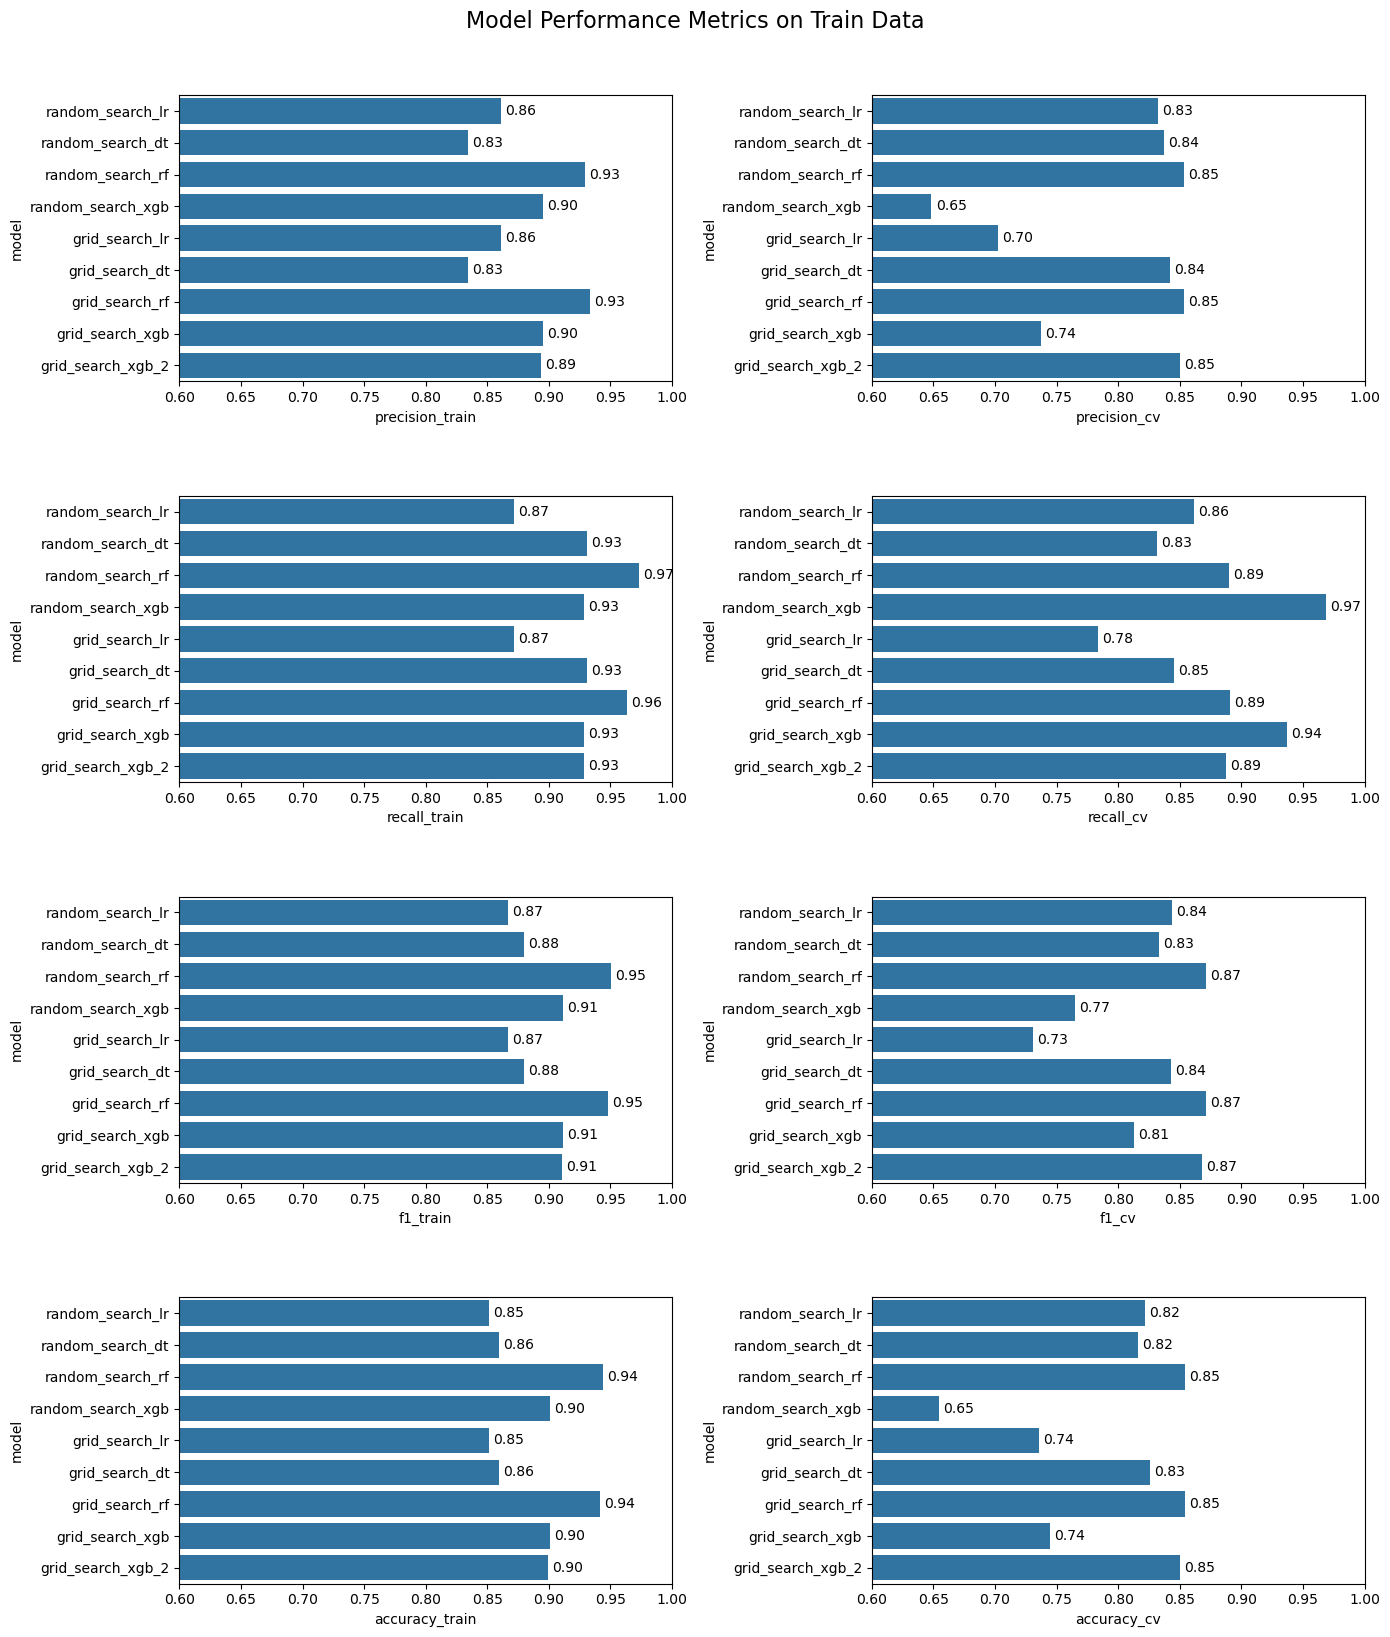

In [60]:
metric_cols_2 = [col for col in results_2_df.columns.tolist()[1:]]

cols = 2
rows = math.ceil(len(metric_cols_2) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(metric_cols_2):
    ax = axes[i]
    sns.barplot(data=results_2_df, x=col, y='model', ax=ax)
    ax.set_xlim(xmin=0.6, xmax=1)
    ax.set_xlabel(col)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)

# hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Model Performance Metrics on Train Data', fontsize=16, y=1.02)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

grid_search_rf still seem to be the better choice. Let's try to tune it to see if we can get a better score.

Accuracy Train = 0.94 | Accuracy CV = 0.85

Precision Train = 0.93 | Precision CV = 0.85

Recall Train = 0.96 | Recall CV = 0.89

F1 Train = 0.95 | F1 CV = 0.87

RandomForestClassifier(max_depth=8, min_samples_split=8, random_state=42)

In [61]:
param_grid_rf_2 = {
    'n_estimators': [90, 150, 200],
    'max_depth': [4, 6, 10],
    'min_samples_split': [10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search_rf_2 = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf_2,
    cv=5,
    scoring=scoring,
    refit='accuracy',
    verbose=1
)

In [62]:
grid_search_rf_2.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [4, 6, 10],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [2, 4], 'min_samples_split': [10],
                         'n_estimators': [90, 150, 200]},
             refit='accuracy',
             scoring={'accuracy': make_scorer(accuracy_score, response_method='predict'),
                      'f1': make_scorer(f1_score, response_method='predict', zero_division=0),
                      'precision': make_scorer(precision_score, response_method='predict', zero_division=0),
                      'recall': make_scorer(recall_score, response_method='predict', zero_division=0)},
             verbose=1)

In [63]:
grid_search_rf_2_best_estimator = grid_search_rf_2.best_estimator_
grid_search_rf_2_best_score = grid_search_rf_2.best_score_
grid_search_rf_2_results_mean_acc = grid_search_rf_2.cv_results_['mean_test_accuracy'].mean()
grid_search_rf_2_results_mean_pre = grid_search_rf_2.cv_results_['mean_test_precision'].mean()
grid_search_rf_2_results_mean_rec = grid_search_rf_2.cv_results_['mean_test_recall'].mean()
grid_search_rf_2_results_mean_f1 = grid_search_rf_2.cv_results_['mean_test_f1'].mean()

print(f"best estimator: {grid_search_rf_2_best_estimator}")
print(f"best score: {grid_search_rf_2_best_score}")
print(f"best cv results mean score accuracy: {grid_search_rf_2_results_mean_acc}")
print(f"best cv results mean score precision: {grid_search_rf_2_results_mean_pre}")
print(f"best cv results mean score recall: {grid_search_rf_2_results_mean_rec}")
print(f"best cv results mean score f1: {grid_search_rf_2_results_mean_f1}")

best estimator: RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=90, random_state=42)
best score: 0.8623520641133166
best cv results mean score accuracy: 0.8568275712111327
best cv results mean score precision: 0.8559319386309567
best cv results mean score recall: 0.8924788383686306
best cv results mean score f1: 0.8733366396394888


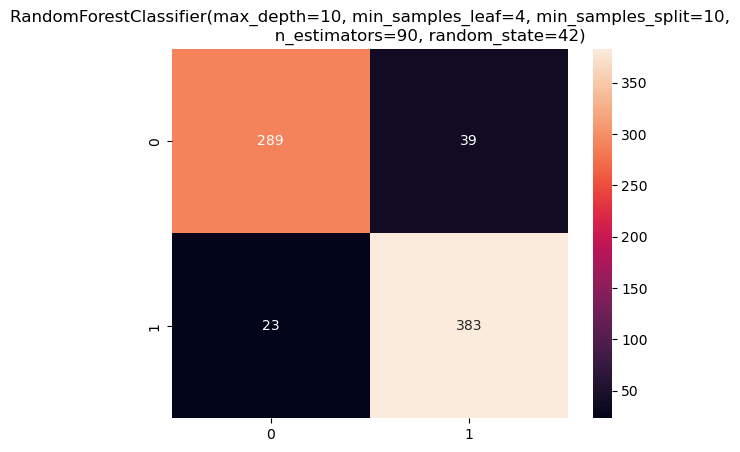

In [64]:
y_train_pred_grid_rf_2 = grid_search_rf_2_best_estimator.predict(X_train_transformed)

plot_confusion_matrix(y_train, y_train_pred_grid_rf_2, grid_search_rf_2_best_estimator)

In [65]:
print(classification_report(y_train, y_train_pred_grid_rf_2))

              precision    recall  f1-score   support

           0       0.93      0.88      0.90       328
           1       0.91      0.94      0.93       406

    accuracy                           0.92       734
   macro avg       0.92      0.91      0.91       734
weighted avg       0.92      0.92      0.92       734



In [66]:
grid_rf_2_pre = precision_score(y_train, y_train_pred_grid_rf_2)
grid_rf_2_rec = recall_score(y_train, y_train_pred_grid_rf_2)
grid_rf_2_f1 = f1_score(y_train, y_train_pred_grid_rf_2)
grid_rf_2_acc = accuracy_score(y_train, y_train_pred_grid_rf_2)

print(f'Train precision: {grid_rf_2_pre} | CV precision: {grid_search_rf_2_results_mean_pre}')
print(f'Train recall: {grid_rf_2_rec} | CV recall: {grid_search_rf_2_results_mean_rec}')
print(f'Train f1: {grid_rf_2_f1} | CV f1: {grid_search_rf_2_results_mean_f1}')
print(f'Train accuracy: {grid_rf_2_acc} | CV accuracy: {grid_search_rf_2_results_mean_acc}')

Train precision: 0.9075829383886256 | CV precision: 0.8559319386309567
Train recall: 0.9433497536945813 | CV recall: 0.8924788383686306
Train f1: 0.9251207729468599 | CV f1: 0.8733366396394888
Train accuracy: 0.9155313351498637 | CV accuracy: 0.8568275712111327


The results above seem to be the most appropriate so far because the gap between the training and CV metrics are less than the first one. This suggests that the model is not overfitting as much as the previous one.

Current parameters: 

RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=10, n_estimators=90, random_state=42)

In [67]:
# retrain model with the chosen params
final_model = RandomForestClassifier(
    max_depth=10, 
    min_samples_leaf=4, 
    min_samples_split=10, 
    n_estimators=90, 
    random_state=42
)

final_model.fit(X_train_transformed, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=90, random_state=42)

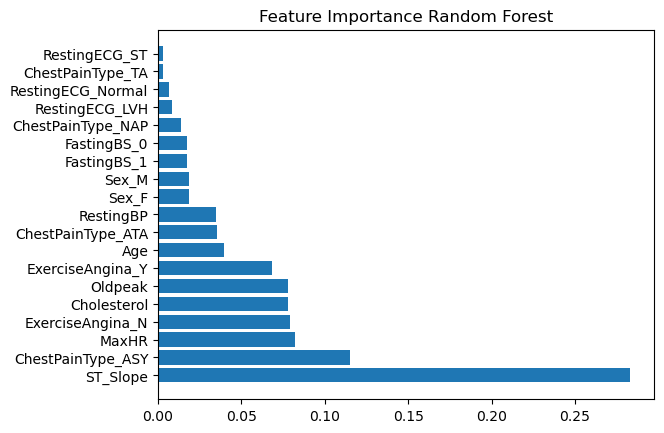

In [68]:
feature_importance = final_model.feature_importances_

feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)
plt.barh(feat_imp_df.feature, feat_imp_df.importance)
plt.title('Feature Importance Random Forest')
plt.show()

In [69]:
# predict on test set
y_pred = final_model.predict(X_test_transformed)
y_scores = final_model.predict_proba(X_test_transformed)[:, 1]

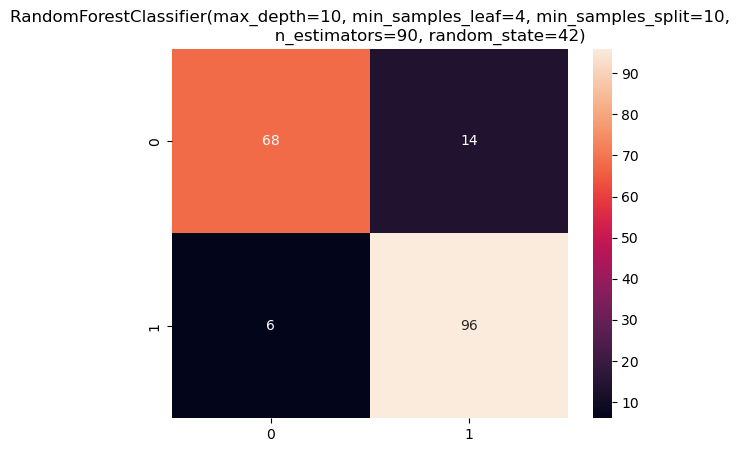

In [70]:
plot_confusion_matrix(y_test, y_pred, final_model)

In [71]:
y_pred_pre = precision_score(y_test, y_pred)
y_pred_rec = recall_score(y_test, y_pred)
y_pred_f1 = f1_score(y_test, y_pred)
y_pred_2_acc = accuracy_score(y_test, y_pred)

print(f'Train precision: {round(grid_rf_2_pre, 2)} | Test precision: {round(y_pred_pre, 2)}')
print(f'Train recall: {round(grid_rf_2_rec, 2)} | Test recall: {round(y_pred_rec, 2)}')
print(f'Train f1: {round(grid_rf_2_f1, 2)} | Test f1: {round(y_pred_f1, 2)}')
print(f'Train accuracy: {round(grid_rf_2_acc, 2)} | Test accuracy: {round(y_pred_2_acc, 2)}')

Train precision: 0.91 | Test precision: 0.87
Train recall: 0.94 | Test recall: 0.94
Train f1: 0.93 | Test f1: 0.91
Train accuracy: 0.92 | Test accuracy: 0.89


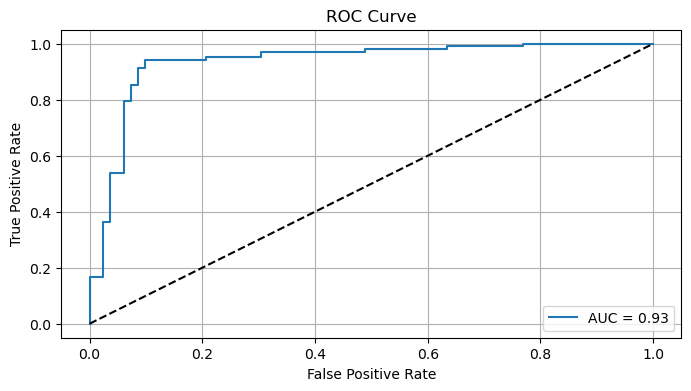

In [72]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(8, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--') # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

/Users/lpt814/anaconda3/envs/ds-personal-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


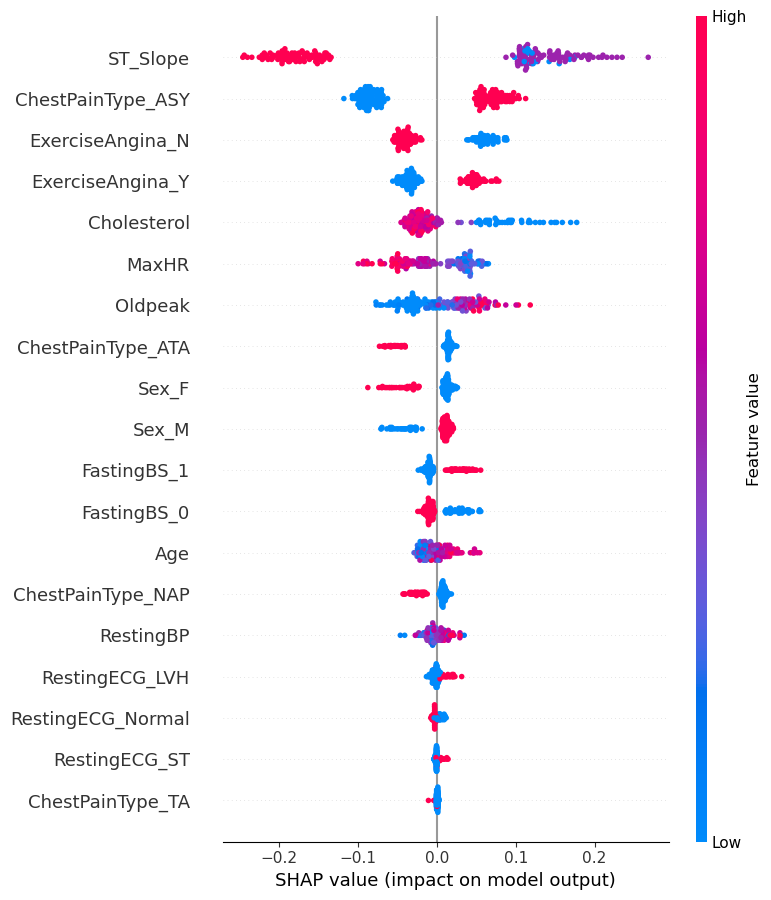

In [73]:
import shap

explainer = shap.TreeExplainer(final_model)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)
shap_values = explainer.shap_values(X_test_transformed_df)
shap.summary_plot(shap_values[:, :, 1], X_test_transformed_df)

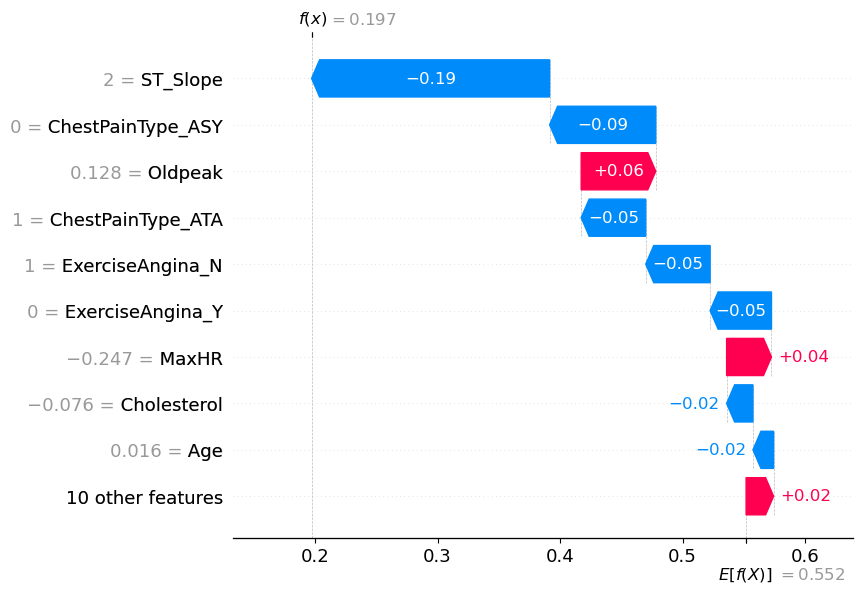

In [74]:
# pick a random sample to look at the local shap value
sample = X_test_transformed_df.iloc[51:52, :]
shap_values_sample = explainer.shap_values(sample)

shap_explanation = shap.Explanation(
    values=shap_values_sample[0, :, 1],
    base_values=explainer.expected_value[1],
    data=sample.values[0], # have to convert df to numpy array
    feature_names=feature_names
)

shap.plots.waterfall(shap_explanation)

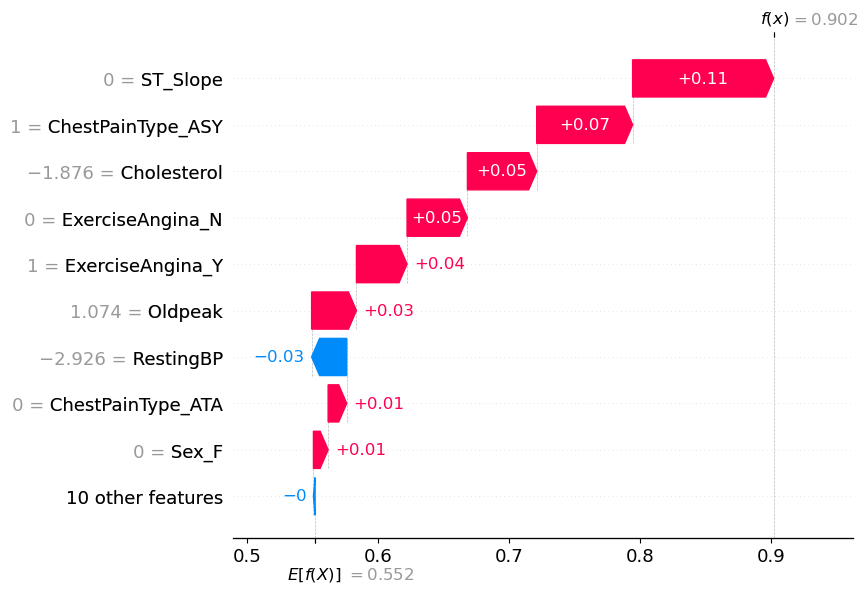

In [75]:
# pick a random sample to look at the local shap value
sample = X_test_transformed_df.iloc[50:51, :]
shap_values_sample = explainer.shap_values(sample)

shap_explanation = shap.Explanation(
    values=shap_values_sample[0, :, 1],
    base_values=explainer.expected_value[1],
    data=sample.values[0], # have to convert df to numpy array
    feature_names=feature_names
)

shap.plots.waterfall(shap_explanation)

In [76]:
display(X_test_transformed_df.iloc[51:52])
print(y_test.iloc[51:52])

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,ST_Slope,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,FastingBS_0,FastingBS_1,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y
51,0.01603,1.501291,-0.07595,-0.247045,0.127695,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


159    0
Name: HeartDisease, dtype: int64


In [77]:
# save model
import joblib

joblib.dump(final_model, './random_forest_heart_disease_model.pkl')

['./random_forest_heart_disease_model.pkl']